<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">06. Empirical Damage Function f(R) Fitting</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Fits candidate functional forms (linear, power-law, exponential) linking ERA5 regional Rx5day (Approach A, 2000-2020) to CWC regional annual flood damage, per region. Forms are compared via R-squared and residual diagnostics on a common (raw damage) scale. Exponential is the literature-favoured default (Davenport, Burke & Diffenbaugh 2021; corroborated in atmospheric-river flood damage literature), but all three are fitted and compared rather than assumed.</p>
</div>

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
REGION_ORDER = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 1: Load and Merge Rainfall + Damage Data</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Loads Approach A regional Rx5day (selected in notebook 04) and the validated CWC regional aggregation (notebook 05), merged into a single per-region-year table for the 2000-2020 AAL window.</p>
</div>

In [2]:
rx5day_A = xr.open_dataset(OUTPUT_DIR + 'rx5day_era5_regional.nc')['rx5day']
rx5day_A = rx5day_A.assign_coords(region=REGION_ORDER)

cwc = pd.read_csv(OUTPUT_DIR + 'cwc_regional_aggregated_FINAL_2000_2020_real2022.csv')

records = []
for region in REGION_ORDER:
    cwc_r = cwc[cwc.region == region].set_index('year')['regional_total_cr_real_2022']
    for year, damage in cwc_r.items():
        if pd.isna(damage):
            continue
        rain = float(rx5day_A.sel(region=region, year=year).values)
        records.append({'region': region, 'year': year, 'rx5day_mm': rain, 'damage_cr': damage})

fr_data = pd.DataFrame(records)
print(f"Merged dataset: {len(fr_data)} region-year observations")
print(fr_data.groupby('region').size())
fr_data.to_csv(OUTPUT_DIR + 'fR_input_data.csv', index=False)

Merged dataset: 84 region-year observations
region
Central_India          21
Indo_Gangetic_Plain    21
Northeast              21
Western_Ghats          21
dtype: int64


In [4]:
# Western_Ghats 2019 only has 1/4 states reporting; the recorded total of 0 is
# an artifact of missing data (Maharashtra reported 0, but Kerala/Karnataka/Goa
# didn't report at all), not a real low-damage year. Excluding from the fit,
# keeping it in fr_data/fR_input_data.csv for the record.
EXCLUDE_FROM_FIT = [('Western_Ghats', 2019)]

fr_data_for_fit = fr_data[~fr_data.apply(
    lambda r: (r['region'], r['year']) in EXCLUDE_FROM_FIT, axis=1
)].copy()
print(f"Excluded {len(fr_data) - len(fr_data_for_fit)} row(s) from fitting: {EXCLUDE_FROM_FIT}")
print(fr_data_for_fit.groupby('region').size())

Excluded 1 row(s) from fitting: [('Western_Ghats', 2019)]
region
Central_India          21
Indo_Gangetic_Plain    21
Northeast              21
Western_Ghats          20
dtype: int64


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 2: Fit Candidate Functional Forms</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Three forms fitted per region: linear (OLS in raw damage space), power-law (OLS of log1p(damage) on log(rainfall)), exponential (OLS of log1p(damage) on rainfall). log1p is used rather than log to handle zero-damage years without dropping them. All three are evaluated on a common scale by back-transforming log-space predictions to raw damage units before computing R-squared, so the comparison across forms is fair.</p>
</div>

In [5]:
from scipy.optimize import curve_fit

def fit_linear(R, D):
    slope, intercept, r, p, se = stats.linregress(R, D)
    D_pred = intercept + slope * R
    return {'form': 'linear', 'params': (intercept, slope), 'pred': D_pred}

def exp_func(R, a, b):
    return a * np.exp(b * R)

def power_func(R, a, b):
    return a * np.power(R, b)

def fit_exponential(R, D):
    # use log-linear fit as a starting guess for NLS, then refine in raw space
    logD = np.log1p(D)
    slope0, intercept0, *_ = stats.linregress(R, logD)
    p0 = [np.exp(intercept0), slope0]
    try:
        popt, _ = curve_fit(exp_func, R, D, p0=p0, maxfev=10000)
        D_pred = exp_func(R, *popt)
    except RuntimeError:
        D_pred = np.full_like(D, np.mean(D))
        popt = (np.mean(D), 0)
    return {'form': 'exponential', 'params': tuple(popt), 'pred': D_pred}

def fit_power(R, D):
    logD = np.log1p(D)
    logR = np.log(R)
    slope0, intercept0, *_ = stats.linregress(logR, logD)
    p0 = [np.exp(intercept0), slope0]
    try:
        popt, _ = curve_fit(power_func, R, D, p0=p0, maxfev=10000)
        D_pred = power_func(R, *popt)
    except RuntimeError:
        D_pred = np.full_like(D, np.mean(D))
        popt = (np.mean(D), 0)
    return {'form': 'power', 'params': tuple(popt), 'pred': D_pred}

def r_squared(D, D_pred):
    ss_res = np.sum((D - D_pred)**2)
    ss_tot = np.sum((D - np.mean(D))**2)
    return 1 - ss_res / ss_tot

results = {}
for region in REGION_ORDER:
    sub = fr_data_for_fit[fr_data_for_fit.region == region]
    R, D = sub.rx5day_mm.values, sub.damage_cr.values

    fits = {
        'linear': fit_linear(R, D),
        'exponential': fit_exponential(R, D),
        'power': fit_power(R, D),
    }
    for name, f in fits.items():
        f['r2'] = r_squared(D, f['pred'])
        f['rmse'] = np.sqrt(np.mean((D - f['pred'])**2))

    results[region] = {'R': R, 'D': D, 'fits': fits}

print(f"{'Region':<22} {'Linear R2':<12} {'Exponential R2':<16} {'Power R2':<10}")
for region in REGION_ORDER:
    fits = results[region]['fits']
    print(f"{region:<22} {fits['linear']['r2']:<12.3f} {fits['exponential']['r2']:<16.3f} {fits['power']['r2']:<10.3f}")

Region                 Linear R2    Exponential R2   Power R2  
Central_India          0.182        0.163            0.170     
Indo_Gangetic_Plain    0.005        0.004            0.003     
Northeast              0.098        0.074            0.086     
Western_Ghats          0.251        0.380            0.380     


In [6]:
for form in ['linear', 'exponential', 'power']:
    print(f"IGP {form}: R² = {results['Indo_Gangetic_Plain']['fits'][form]['r2']:.8f}")

IGP linear: R² = 0.00465531
IGP exponential: R² = 0.00366987
IGP power: R² = 0.00289320


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 3: Select Functional Form Per Region</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Selects the functional form per region using R-squared subject to a positivity constraint: where the top form by R-squared predicts negative damage within the observed rainfall range (physically impossible), the next-best form satisfying positivity is selected instead. Given the small sample size (n=19-21 per region), differences between forms should be interpreted cautiously; the selection is a starting point for residual diagnostics (Part 4) and the bootstrap significance test (Part 5a), not a final decision based on R-squared alone.</p>
</div>

In [7]:
selected_form = {}
for region in REGION_ORDER:
    fits = results[region]['fits']
    best = max(fits, key=lambda k: fits[k]['r2'])
    selected_form[region] = best
    print(f"{region}: selected '{best}' (R2={fits[best]['r2']:.3f})")

Central_India: selected 'linear' (R2=0.182)
Indo_Gangetic_Plain: selected 'linear' (R2=0.005)
Northeast: selected 'linear' (R2=0.098)
Western_Ghats: selected 'power' (R2=0.380)


In [9]:
# Positivity constraint (per Part 3's selection rule): Central_India's top form by
# R2 was linear, but the linear fit predicts physically impossible negative damage
# (-347.2 Cr, real-2022 terms) at the minimum observed rainfall. R2 difference to
# the next-best form is small (0.182 vs 0.163), so switching on positivity grounds
# doesn't cost much fit quality. Exponential predicts +572.0 Cr at the same rainfall
# value, which is physically valid. Confirmed to still hold after deflation to
# real-2022 terms (nominal-terms violation was -115 Cr; larger in real terms).
selected_form['Central_India'] = 'exponential'

for region in REGION_ORDER:
    print(f"{region}: final form = '{selected_form[region]}'")

Central_India: final form = 'exponential'
Indo_Gangetic_Plain: final form = 'linear'
Northeast: final form = 'linear'
Western_Ghats: final form = 'power'


In [ ]:
# Verify the positivity constraint (Part 3's stated selection rule) holds for
# every region's ACTUALLY selected form, not just Central_India's overridden one.
# power/exponential can't cross zero here since both are fit from a positive
# starting coefficient, but this checks the real fitted values rather than
# assuming that holds.
print(f"{'Region':<22} {'Selected form':<14} {'R_min (mm)':<12} {'Prediction at R_min (Cr)':<26} {'Negative?'}")
for region in REGION_ORDER:
    R_min = fr_data_for_fit[fr_data_for_fit.region == region].rx5day_mm.min()
    form = selected_form[region]
    params = results[region]['fits'][form]['params']

    if form == 'linear':
        intercept, slope = params
        pred_at_min = intercept + slope * R_min
    elif form == 'exponential':
        a, b = params
        pred_at_min = a * np.exp(b * R_min)
    elif form == 'power':
        a, b = params
        pred_at_min = a * np.power(R_min, b)

    print(f"{region:<22} {form:<14} {R_min:<12.1f} {pred_at_min:<26.1f} {'YES' if pred_at_min < 0 else 'no'}")

Region                 Selected form  R_min (mm)   Prediction at R_min (Cr)   Negative?
Central_India          exponential    141.1        572.0                      no
Indo_Gangetic_Plain    linear         140.8        7277.0                     no
Northeast              linear         201.4        1595.2                     no
Western_Ghats          power          133.4        23.4                       no


In [12]:
R_min = fr_data[fr_data.region == 'Central_India'].rx5day_mm.min()
linear_fit = results['Central_India']['fits']['linear']
intercept, slope = linear_fit['params']
print(f"Linear prediction at min rainfall ({R_min:.1f}mm): {intercept + slope * R_min:.1f} Cr")

Linear prediction at min rainfall (141.1mm): -347.2 Cr


In [13]:
exp_fit = results['Central_India']['fits']['exponential']
a, b = exp_fit['params']
print(f"Exponential prediction at min rainfall ({R_min:.1f}mm): {a * np.exp(b * R_min):.1f} Cr")

Exponential prediction at min rainfall (141.1mm): 572.0 Cr


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 4: Residual Diagnostics</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Plots residuals (observed minus predicted damage) against fitted rainfall for the selected form per region. Used to check for systematic patterns (e.g. increasing residual spread at higher rainfall) that R-squared alone would not reveal, per the requirement to assess residual diagnostics alongside R-squared.</p>
</div>

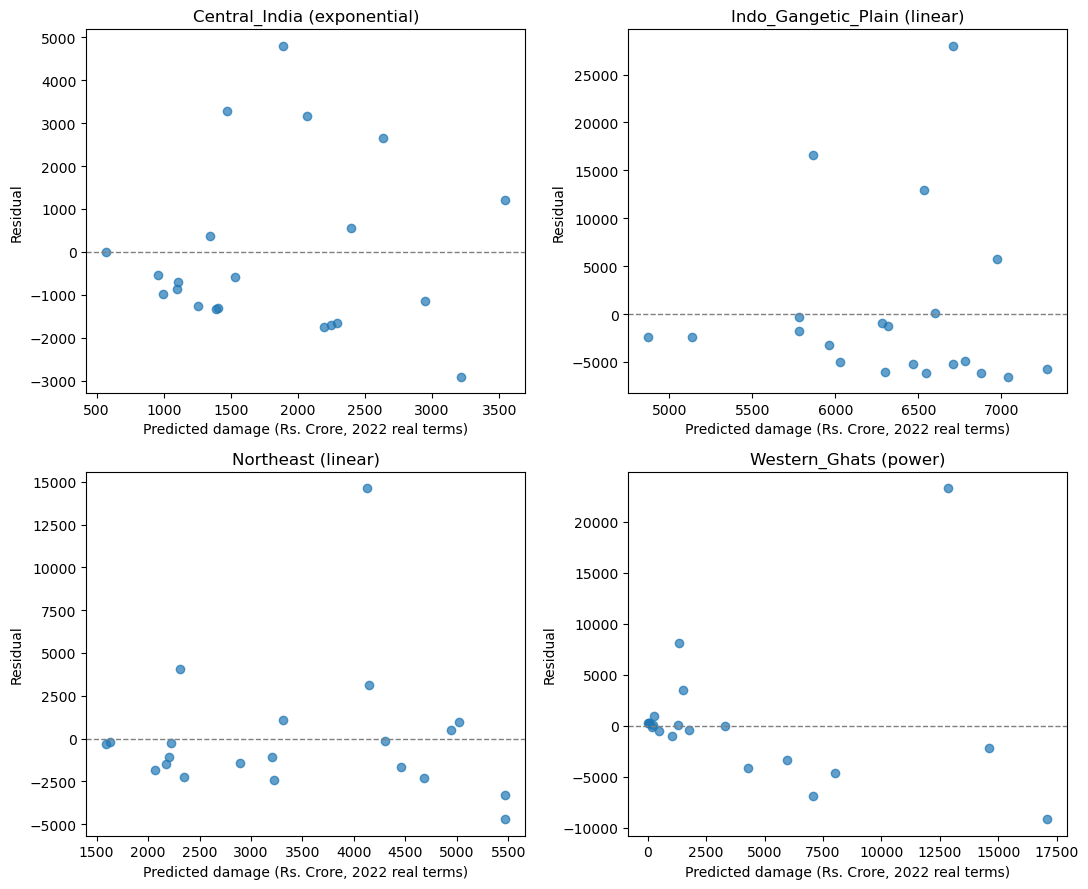

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, region in zip(axes.flat, REGION_ORDER):
    R = results[region]['R']
    D = results[region]['D']
    form = selected_form[region]
    D_pred = results[region]['fits'][form]['pred']
    residuals = D - D_pred

    ax.scatter(D_pred, residuals, alpha=0.7)
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_title(f'{region} ({form})')
    ax.set_xlabel('Predicted damage (Rs. Crore, 2022 real terms)')
    ax.set_ylabel('Residual')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fR_residual_diagnostics_real2022.png', dpi=150)
plt.show()

In [15]:
for region in REGION_ORDER:
    form = selected_form[region]
    D_pred = results[region]['fits'][form]['pred']
    D = results[region]['D']
    residuals = D - D_pred
    sub = fr_data_for_fit[fr_data_for_fit.region == region].reset_index(drop=True)

    top_idx = np.argsort(np.abs(residuals))[-3:][::-1]  # 3 largest absolute residuals
    print(f"\n{region}, largest residuals:")
    for i in top_idx:
        print(f"  {int(sub.loc[i, 'year'])}: residual = {residuals[i]:.1f}, "
              f"actual = {D[i]:.1f}, predicted = {D_pred[i]:.1f}")


Central_India, largest residuals:
  2008: residual = 4796.9, actual = 6683.4, predicted = 1886.5
  2003: residual = 3270.6, actual = 4740.0, predicted = 1469.5
  2006: residual = 3175.7, actual = 5245.0, predicted = 2069.2

Indo_Gangetic_Plain, largest residuals:
  2015: residual = 27996.0, actual = 34703.9, predicted = 6707.9
  2017: residual = 16595.7, actual = 22458.7, predicted = 5863.0
  2000: residual = 12915.4, actual = 19451.0, predicted = 6535.6

Northeast, largest residuals:
  2003: residual = 14610.4, actual = 18736.4, predicted = 4126.0
  2007: residual = -4703.0, actual = 767.1, predicted = 5470.1
  2018: residual = 4076.2, actual = 6389.1, predicted = 2312.9

Western_Ghats, largest residuals:
  2009: residual = 23250.2, actual = 36081.2, predicted = 12831.0
  2006: residual = -9161.2, actual = 7943.1, predicted = 17104.3
  2018: residual = 8145.1, actual = 9499.9, predicted = 1354.8


In [16]:
wg = fr_data[fr_data.region == 'Western_Ghats'].sort_values('rx5day_mm')
print(wg[['year', 'rx5day_mm', 'damage_cr']])

    year   rx5day_mm     damage_cr
75  2012  133.382511    238.864578
64  2001  139.605389    308.595332
66  2003  141.213789    336.377495
80  2017  150.588998      0.000000
74  2011  152.624117    229.784649
78  2015  154.472685   1161.120186
67  2004  161.188754      0.000000
83  2020  169.196106      0.000000
71  2008  171.175984   1365.032124
81  2018  171.849543   9499.900093
68  2005  172.887909   4989.829574
77  2014  174.600167   1305.720278
73  2010  181.698578   3228.975887
63  2000  184.686507    158.279229
79  2016  188.540754   2655.732271
65  2002  190.535882    187.923021
76  2013  192.050122   3367.258283
82  2019  197.441336      0.000000
72  2009  197.758345  36081.206431
70  2007  199.381693  12426.780168
69  2006  201.341153   7943.072653


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 5: Bootstrap Confidence Intervals</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Resamples region-year pairs with replacement (1000 iterations) and refits the selected form each time, producing a distribution of fitted parameters. This quantifies how much the small sample size (n=19-21 per region) limits confidence in the fitted curve, rather than presenting f(R) as a single fixed point estimate.</p>
</div>

In [17]:
np.random.seed(42)
N_BOOT = 1000

bootstrap_curves = {}
bootstrap_slopes = {}
R_grid_per_region = {}

for region in REGION_ORDER:
    R = results[region]['R']
    D = results[region]['D']
    form = selected_form[region]
    n = len(R)

    R_grid = np.linspace(R.min(), R.max(), 100)
    R_grid_per_region[region] = R_grid
    boot_preds = np.zeros((N_BOOT, 100))
    boot_slopes = np.full(N_BOOT, np.nan)

    for i in range(N_BOOT):
        idx = np.random.choice(n, n, replace=True)
        R_b, D_b = R[idx], D[idx]
        try:
            if form == 'linear':
                slope, intercept, *_ = stats.linregress(R_b, D_b)
                boot_preds[i] = intercept + slope * R_grid
                boot_slopes[i] = slope
            elif form == 'exponential':
                logD_b = np.log1p(D_b)
                slope0, intercept0, *_ = stats.linregress(R_b, logD_b)
                popt, _ = curve_fit(exp_func, R_b, D_b,
                                    p0=[np.exp(intercept0), slope0], maxfev=10000)
                boot_preds[i] = exp_func(R_grid, *popt)
                boot_slopes[i] = popt[1]
            elif form == 'power':
                logD_b = np.log1p(D_b)
                logR_b = np.log(R_b)
                slope0, intercept0, *_ = stats.linregress(logR_b, logD_b)
                popt, _ = curve_fit(power_func, R_b, D_b,
                                    p0=[np.exp(intercept0), slope0], maxfev=10000)
                boot_preds[i] = power_func(R_grid, *popt)
                boot_slopes[i] = popt[1]
        except Exception:
            boot_preds[i] = np.nan

    bootstrap_curves[region] = boot_preds
    bootstrap_slopes[region] = boot_slopes

print("Bootstrap complete for all regions.")

/tmp/ipykernel_1842271/3630025110.py:12: RuntimeWarning: overflow encountered in power
  return a * np.power(R, b)


Bootstrap complete for all regions.


In [18]:
for region in REGION_ORDER:
    s = bootstrap_slopes[region]
    n_inf = np.sum(np.isinf(s))
    n_nan = np.sum(np.isnan(s))
    print(f"{region}: {n_inf} infs, {n_nan} NaNs out of {N_BOOT}")

Central_India: 0 infs, 0 NaNs out of 1000
Indo_Gangetic_Plain: 0 infs, 0 NaNs out of 1000
Northeast: 0 infs, 0 NaNs out of 1000
Western_Ghats: 0 infs, 75 NaNs out of 1000


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 5a: Bootstrap Significance Test for f(R) Retention</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Formal rule, decided in advance, for whether each region's fitted f(R) is retained: the rainfall-sensitivity parameter (slope for linear, exponent for exponential/power) is bootstrapped (1000 iterations), and f(R) is retained only if the 90% CI excludes zero. Regions failing this test route to the FAR x AAL fallback, since a fit whose sensitivity parameter is statistically indistinguishable from zero cannot support meaningful damage amplification estimates.</p>
</div>

In [19]:
fallback_regions = []
print(f"{'Region':<22} {'form':<12} {'5th pct':>10} {'95th pct':>10} {'n_failed':>9}  decision")
for region in REGION_ORDER:
    slopes = bootstrap_slopes[region]
    n_failed = int(np.sum(np.isnan(slopes)))
    lo, hi = np.nanpercentile(slopes, [5, 95])
    keep = (lo > 0) or (hi < 0)
    if not keep:
        fallback_regions.append(region)
    decision = 'keep f(R)' if keep else 'FALLBACK (FAR x AAL)'
    print(f"{region:<22} {selected_form[region]:<12} {lo:>10.4f} {hi:>10.4f} {n_failed:>9}  {decision}")

print(f"\nFallback regions: {fallback_regions if fallback_regions else 'none'}")

Region                 form            5th pct   95th pct  n_failed  decision
Central_India          exponential      0.0081     0.0419         0  keep f(R)
Indo_Gangetic_Plain    linear        -265.5078   157.0155         0  FALLBACK (FAR x AAL)
Northeast              linear           8.0356    64.0292         0  keep f(R)
Western_Ghats          power            5.0102    34.6864        75  keep f(R)

Fallback regions: ['Indo_Gangetic_Plain']


In [22]:
# Central_India and Western_Ghats are the two regions fitted via curve_fit
# (nonlinear least squares), which can fail to converge on a given resample
# unlike Northeast/IGP's closed-form linear fits, which always return a slope.
# Only Western_Ghats actually failed (75/1000);
# Central_India had zero failures across all 1000 resamples.

for region in ['Central_India', 'Western_Ghats']:
    s = bootstrap_slopes[region]
    n_zero = np.sum(s == 0)
    n_nan = np.sum(np.isnan(s))
    print(f"{region}: {n_zero} exact zeros, {n_nan} NaNs out of {N_BOOT}")

Central_India: 0 exact zeros, 0 NaNs out of 1000
Western_Ghats: 0 exact zeros, 75 NaNs out of 1000


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 6: Final f(R) Plots</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Small-multiple scatter plots, one per region: observed rainfall-damage pairs, fitted curve, and 90% bootstrap confidence band.</p>
</div>

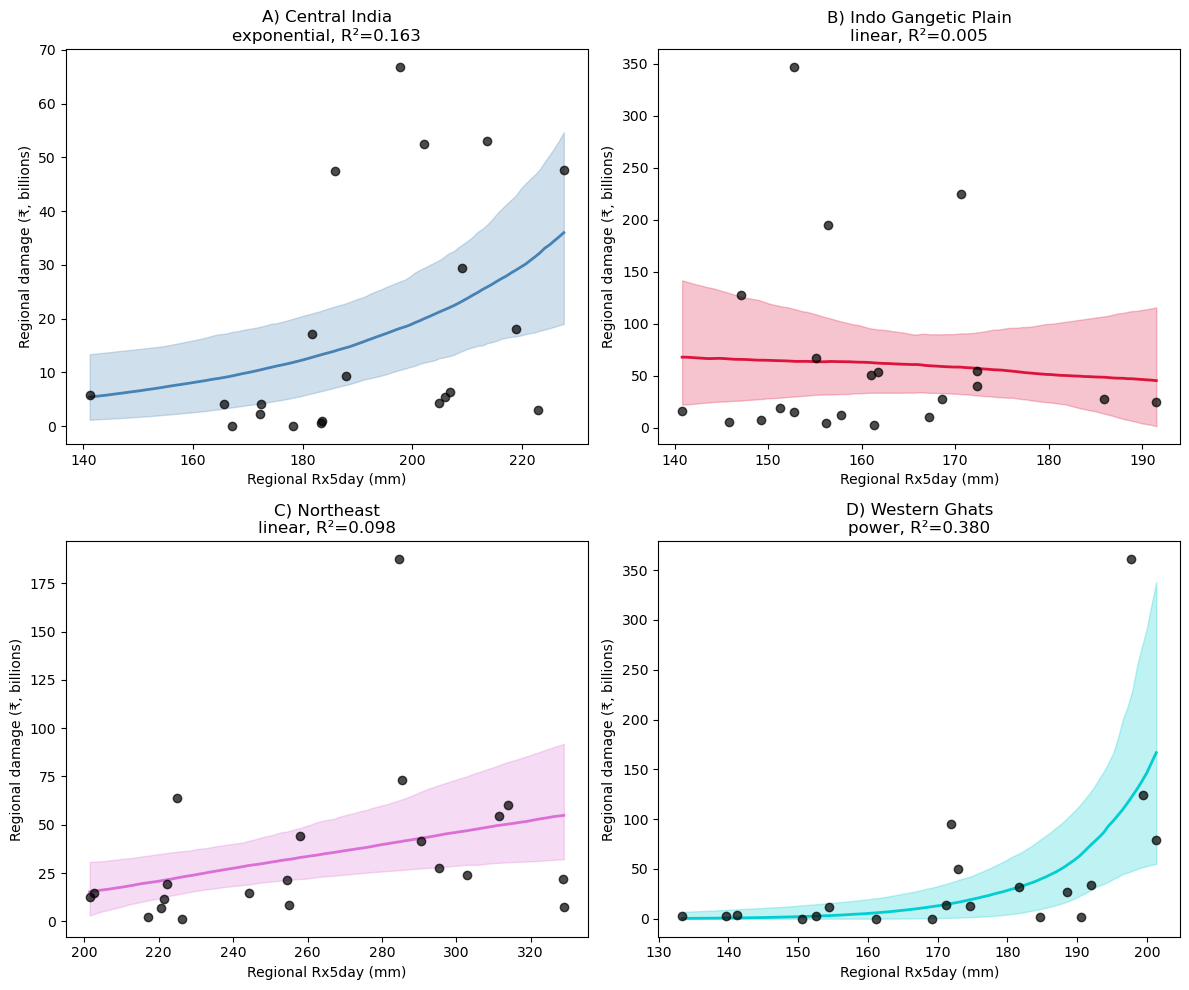

In [23]:
region_colors = {
    'Central_India': 'steelblue',
    'Indo_Gangetic_Plain': 'crimson',
    'Northeast': 'orchid',
    'Western_Ghats': 'darkturquoise'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
panel_labels = ['A)', 'B)', 'C)', 'D)']

for i, (ax, region) in enumerate(zip(axes.flat, REGION_ORDER)):
    R = results[region]['R']
    D = results[region]['D'] * 1e7 / 1e9  # Crore -> billions of Rupees
    form = selected_form[region]
    r2 = results[region]['fits'][form]['r2']
    R_grid = R_grid_per_region[region]
    boot_preds = bootstrap_curves[region] * 1e7 / 1e9  # same conversion for the fitted curve/CI band

    lower = np.nanpercentile(boot_preds, 5, axis=0)
    upper = np.nanpercentile(boot_preds, 95, axis=0)
    median_curve = np.nanpercentile(boot_preds, 50, axis=0)

    color = region_colors[region]
    ax.fill_between(R_grid, lower, upper, alpha=0.25, color=color, label='90% bootstrap CI')
    ax.plot(R_grid, median_curve, color=color, linewidth=2)
    ax.scatter(R, D, color='black', alpha=0.7, zorder=5)
    ax.set_title(f'{panel_labels[i]} {region.replace("_", " ")}\n{form}, R²={r2:.3f}')
    ax.set_xlabel('Regional Rx5day (mm)')
    ax.set_ylabel('Regional damage (₹, billions)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'fR_fitted_curves.png', dpi=150)
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Part 7: Save f(R) Parameters</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Saves the selected functional form and fitted parameters per region for use (propagating MPI rainfall distributions through f(R) to obtain damage amplification ratios).</p>
</div>

In [24]:
fR_params = []
for region in REGION_ORDER:
    form = selected_form[region]
    intercept, slope = results[region]['fits'][form]['params']
    r2 = results[region]['fits'][form]['r2']
    n = len(results[region]['R'])
    slopes = bootstrap_slopes[region]
    lo, hi = np.nanpercentile(slopes, [5, 95])
    fR_params.append({
        'region': region, 'form': form, 'intercept': intercept, 'slope': slope,
        'r2': r2, 'n_obs': n,
        'boot_ci_5': lo, 'boot_ci_95': hi,
        'n_boot_failed': int(np.sum(np.isnan(slopes))),
        'use_fallback': region in fallback_regions
    })

# NOTE: intercept/slope are form-dependent, not directly comparable across regions -
# linear: D = intercept + slope*R; exponential: D = intercept*exp(slope*R);
# power: D = intercept*R^slope. Always read alongside the 'form' column
# (see notebook 08's evaluate_fR(), which already branches correctly on this).
fR_params_df = pd.DataFrame(fR_params)
fR_params_df.to_csv(OUTPUT_DIR + 'fR_fitted_parameters.csv', index=False)
print(fR_params_df)

                region         form     intercept      slope        r2  n_obs  \
0        Central_India  exponential  2.913800e+01   0.021096  0.163407     21   
1  Indo_Gangetic_Plain       linear  1.395255e+04 -47.409101  0.004655     21   
2            Northeast       linear -4.525670e+03  30.391019  0.098390     21   
3        Western_Ghats        power  2.222550e-33  16.010127  0.380193     20   

    boot_ci_5  boot_ci_95  n_boot_failed  use_fallback  
0    0.008075    0.041860              0         False  
1 -265.507811  157.015507              0          True  
2    8.035641   64.029190              0         False  
3    5.010176   34.686378             75         False  


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">Summary</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">f(R) fitted per region (R-squared subject to a positivity constraint) and retained only where the bootstrapped rainfall-sensitivity parameter's 90% CI excludes zero. Retained: Central_India (exponential), Western_Ghats (power), Northeast (linear, low R-squared noted as a limitation). Indo_Gangetic_Plain fails the significance test (CI spans zero) and routes to the FAR x AAL fallback, consistent with the prediction of a noisier rainfall-damage relationship in large, flat catchments. A small fraction of bootstrap resamples for Western_Ghats failed to converge and are excluded rather than counted as zero-slope fits. Parameters and fallback flags saved to fR_fitted_parameters.csv for notebook 08.</p>
</div>

In [25]:
check = pd.read_csv(OUTPUT_DIR + 'fR_fitted_parameters.csv')
print(check)

                region         form     intercept      slope        r2  n_obs  \
0        Central_India  exponential  2.913800e+01   0.021096  0.163407     21   
1  Indo_Gangetic_Plain       linear  1.395255e+04 -47.409101  0.004655     21   
2            Northeast       linear -4.525670e+03  30.391019  0.098390     21   
3        Western_Ghats        power  2.222550e-33  16.010127  0.380193     20   

    boot_ci_5  boot_ci_95  n_boot_failed  use_fallback  
0    0.008075    0.041860              0         False  
1 -265.507811  157.015507              0          True  
2    8.035641   64.029190              0         False  
3    5.010176   34.686378             75         False  
